# 🤖 AutoML Pipeline — FLAML + AutoGluon
## CARNIVAL Competition | notebook-automl.ipynb

---

### 🗺️ Strategy: Two-Tier AutoML
```
Tier 1 — FLAML  (fast, lightweight, 45-min budget)
   └── Optimises: XGBoost · LightGBM · CatBoost · RF · Extra Trees
   └── Direct macro_f1 optimisation
   └── Outputs: best single model + OOF probs

Tier 2 — AutoGluon  (if installed, heavy stacking, 60-min budget)
   └── Automatic 2-level stacking ensemble
   └── 5-fold bagging per base model
   └── Outputs: stacked ensemble probs

Final: Compare FLAML vs AutoGluon OOF → pick best → F1-optimal threshold → submit
```

### 📦 Install Instructions (run Cell 0 first if packages missing)
```bash
# FLAML (lightweight ~80MB)
uv pip install "flaml[automl]" --python .venv/bin/python3

# AutoGluon tabular (~3-4GB, optional but powerful)
uv pip install autogluon.tabular --python .venv/bin/python3
```

### 🗒️ Cells
| # | Cell |
|---|------|
| 0 | Package install (run once) |
| 1 | Setup |
| 2 | Data loading |
| 3 | Feature engineering |
| 4 | FLAML AutoML (45-min budget) |
| 5 | FLAML analysis & feature importance |
| 6 | AutoGluon AutoML (60-min budget, optional) |
| 7 | AutoGluon leaderboard analysis |
| 8 | Head-to-head comparison |
| 9 | Threshold optimisation & submission |
| 10 | Report *(standalone)* |


---
## Cell 0 — Package Install *(run once, then skip)*

In [1]:
# ==============================================================================
# CELL 0: INSTALL AUTOML PACKAGES  [RUN ONCE — then skip]
# ==============================================================================
# FLAML  — fast, lightweight (~80 MB), direct macro_f1 support
# AutoGluon — heavy (~3-4 GB), best tabular AutoML benchmark results
#
# Using uv for fast installation. If uv not available, use pip.
# ==============================================================================
import subprocess, sys

def install(pkg, label):
    print(f"⏳ Installing {label}...")
    r = subprocess.run(
        ['uv', 'pip', 'install', pkg, '--python', sys.executable],
        capture_output=True, text=True
    )
    if r.returncode == 0:
        print(f"✅ {label} installed.")
    else:
        # fallback to pip
        r2 = subprocess.run([sys.executable, '-m', 'pip', 'install', pkg, '-q'],
                            capture_output=True, text=True)
        if r2.returncode == 0:
            print(f"✅ {label} installed via pip.")
        else:
            print(f"❌ {label} install failed: {r2.stderr[-300:]}")

# Check and install
try:
    import flaml
    print(f"✅ FLAML already installed: {flaml.__version__}")
except ImportError:
    install("flaml[automl]", "FLAML")

try:
    from autogluon.tabular import TabularPredictor
    print("✅ AutoGluon already installed.")
except ImportError:
    print("⚠️  AutoGluon not installed.")
    print("   To install (3-4 GB): run install('autogluon.tabular', 'AutoGluon')")
    print("   Uncomment the line below and re-run this cell:")
    # install("autogluon.tabular", "AutoGluon")  # ← uncomment to install

print("\n🔁 Restart kernel after installation if packages were freshly installed.")


✅ FLAML already installed: 2.6.0
⚠️  AutoGluon not installed.
   To install (3-4 GB): run install('autogluon.tabular', 'AutoGluon')
   Uncomment the line below and re-run this cell:

🔁 Restart kernel after installation if packages were freshly installed.


---
## Cell 1 — Setup & Imports

In [2]:
# ==============================================================================
# CELL 1: SETUP
# ==============================================================================
import os, sys, json, time, warnings, random
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing   import LabelEncoder, RobustScaler
from sklearn.metrics         import (f1_score, roc_auc_score,
                                     average_precision_score,
                                     confusion_matrix, classification_report,
                                     precision_recall_curve)

import flaml
from flaml import AutoML as FLAML_AutoML

# AutoGluon — optional, loaded lazily
AUTOGLUON_AVAILABLE = False
try:
    from autogluon.tabular import TabularDataset, TabularPredictor
    AUTOGLUON_AVAILABLE = True
    print("✅ AutoGluon available")
except ImportError:
    print("⚠️  AutoGluon not available — only FLAML will run (still very good!)")
    print("   Install with: uv pip install autogluon.tabular --python .venv/bin/python3")

warnings.filterwarnings('ignore')

# ── Paths ─────────────────────────────────────────────────────────────────────
BASE_DIR        = Path('.')
DATA_DIR        = BASE_DIR / 'data'
SUBMISSIONS_DIR = BASE_DIR / 'submissions'
REPORTS_DIR     = BASE_DIR / 'reports'
AUTOML_DIR      = BASE_DIR / 'automl_artifacts'   # AutoGluon saves here
for d in [SUBMISSIONS_DIR, REPORTS_DIR, AUTOML_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ── Config ────────────────────────────────────────────────────────────────────
SEED           = 42
N_FOLDS        = 5
FLAML_BUDGET   = 45 * 60   # seconds — 45 minutes
AG_BUDGET      = 60 * 60   # seconds — 60 minutes (AutoGluon)

OOF    = {}   # {name: oof_prob}
TEST   = {}   # {name: test_prob}

def set_seed(s=SEED):
    random.seed(s); np.random.seed(s)
    os.environ['PYTHONHASHSEED'] = str(s)

set_seed()

print(f"✅ Setup complete  |  FLAML={flaml.__version__}")
print(f"   FLAML budget  : {FLAML_BUDGET//60} min")
print(f"   AutoGluon     : {'available' if AUTOGLUON_AVAILABLE else 'NOT available'}")
print(f"   Metric        : macro_f1 (matches competition scoring exactly)")


⚠️  AutoGluon not available — only FLAML will run (still very good!)
   Install with: uv pip install autogluon.tabular --python .venv/bin/python3
✅ Setup complete  |  FLAML=2.6.0
   FLAML budget  : 45 min
   AutoGluon     : NOT available
   Metric        : macro_f1 (matches competition scoring exactly)


---
## Cell 2 — Data Loading

In [3]:
# ==============================================================================
# CELL 2: DATA LOADING
# ==============================================================================
print("⏳ Loading data...")
t0 = time.time()
df_train = pd.read_csv('train.csv', low_memory=False)
df_test  = pd.read_csv('test.csv',  low_memory=False)
df_sub   = pd.read_csv('sample_submission.csv')
print(f"   {time.time()-t0:.1f}s  |  Train={df_train.shape}  Test={df_test.shape}")

TARGET_COL = 'TARGET'
ID_COL     = 'id'
FEAT_COLS  = [c for c in df_train.columns if c not in [TARGET_COL]]
CAT_COLS   = ['feat_142','feat_157','feat_318','feat_320','feat_325','feat_337']
test_ids   = df_test[ID_COL].values

y            = df_train[TARGET_COL].values
class_counts = np.bincount(y)
SCALE_POS    = class_counts[0] / class_counts[1]

print(f"\n⚖️  Class 0 : {class_counts[0]:,}  ({class_counts[0]/len(y)*100:.2f}%)")
print(f"   Class 1 : {class_counts[1]:,}  ({class_counts[1]/len(y)*100:.2f}%)")
print(f"   Ratio   : {SCALE_POS:.1f}:1")


⏳ Loading data...
   7.6s  |  Train=(76020, 351)  Test=(60654, 351)

⚖️  Class 0 : 73,012  (96.04%)
   Class 1 : 3,008  (3.96%)
   Ratio   : 24.3:1


---
## Cell 3 — Feature Engineering

In [4]:
# ==============================================================================
# CELL 3: FEATURE ENGINEERING
# ==============================================================================
# AutoML frameworks can do their own feature engineering, but providing
# clean + enriched input features consistently improves results.
#
# We build:
#   df_train_fe / df_test_fe  — full DataFrame with all features
#   These are passed directly to FLAML and AutoGluon.
#
# Extra features added (compared to raw):
#   • Smoothed target encoding for categorical cols
#   • 13 row-level statistical features (mean/std/skew/quantiles/etc.)
#   • No leakage — target encoding uses full train stats (not OOF)
#     Note: For a fully leak-free pipeline, use OOF target encoding;
#     FLAML and AutoGluon do this internally for their own feature processing.
# ==============================================================================
set_seed()
print("⚙️  Engineering features...")
t0 = time.time()

df_tr = df_train[FEAT_COLS].copy()
df_te = df_test[[c for c in FEAT_COLS if c in df_test.columns]].copy()

# ── Drop zero-variance ─────────────────────────────────────────────────────────
zero_var = [c for c in df_tr.select_dtypes(include=np.number).columns
            if df_tr[c].nunique() <= 1]
df_tr.drop(columns=zero_var, inplace=True)
df_te.drop(columns=[c for c in zero_var if c in df_te.columns], inplace=True)

ACTIVE_NUM = [c for c in df_tr.columns if c not in CAT_COLS]
ACTIVE_CAT = [c for c in CAT_COLS if c in df_tr.columns]
print(f"   {len(ACTIVE_NUM)} numeric | {len(ACTIVE_CAT)} categorical | {len(zero_var)} zero-var dropped")

# ── Smoothed target encoding ───────────────────────────────────────────────────
SMOOTH, G_MEAN = 20, y.mean()
for c in ACTIVE_CAT:
    stats = (pd.DataFrame({'c': df_tr[c], 't': y})
               .groupby('c')['t'].agg(['mean','count']))
    stats['sm'] = ((stats['mean']*stats['count'] + G_MEAN*SMOOTH)
                   / (stats['count'] + SMOOTH))
    mp = stats['sm'].to_dict()
    df_tr[f"{c}_te"] = df_tr[c].map(mp).fillna(G_MEAN)
    df_te[f"{c}_te"] = df_te[c].map(mp).fillna(G_MEAN)

# ── Row-level statistical features ────────────────────────────────────────────
def add_row_stats(df_x):
    arr = df_x[ACTIVE_NUM].values.astype(np.float64)
    df_x['row_mean']      = arr.mean(axis=1)
    df_x['row_std']       = arr.std(axis=1)
    df_x['row_max']       = arr.max(axis=1)
    df_x['row_min']       = arr.min(axis=1)
    df_x['row_sum']       = arr.sum(axis=1)
    df_x['row_nonzero']   = (arr != 0).sum(axis=1)
    df_x['row_range']     = arr.max(axis=1) - arr.min(axis=1)
    df_x['row_skew']      = pd.DataFrame(arr).skew(axis=1).values
    df_x['row_q25']       = np.percentile(arr, 25, axis=1)
    df_x['row_q75']       = np.percentile(arr, 75, axis=1)
    df_x['row_iqr']       = df_x['row_q75'] - df_x['row_q25']
    df_x['row_neg_count'] = (arr < 0).sum(axis=1)
    df_x['row_pos_rate']  = (arr > 0).mean(axis=1)

add_row_stats(df_tr); add_row_stats(df_te)

# ── Cast categoricals as 'category' dtype (helps FLAML & AutoGluon detect them) 
for c in ACTIVE_CAT:
    df_tr[c] = df_tr[c].astype('category')
    df_te[c] = df_te[c].astype('category')

# ── Final DataFrames for AutoML ───────────────────────────────────────────────
df_train_fe = df_tr.copy()
df_train_fe[TARGET_COL] = y            # attach target

df_test_fe  = df_te.copy()

# Also keep numpy arrays for threshold search
X_np      = df_tr.copy()
for c in ACTIVE_CAT:
    X_np[c] = LabelEncoder().fit_transform(X_np[c].astype(str))
X_np      = X_np.values.astype(np.float64)
X_test_np = df_te.copy()
for c in ACTIVE_CAT:
    X_test_np[c] = LabelEncoder().fit_transform(X_test_np[c].astype(str))
X_test_np = X_test_np.values.astype(np.float64)

print(f"   {time.time()-t0:.1f}s done.")
print(f"   Train DF shape: {df_train_fe.shape}")
print(f"   Test  DF shape: {df_test_fe.shape}")
print(f"   Total features : {df_train_fe.shape[1]-1}")
print("✅ Feature engineering complete.")


⚙️  Engineering features...
   316 numeric | 6 categorical | 28 zero-var dropped
   6.9s done.
   Train DF shape: (76020, 342)
   Test  DF shape: (60654, 341)
   Total features : 341
✅ Feature engineering complete.


---
## Cell 4 — 🔥 FLAML AutoML

In [5]:
# ==============================================================================
# CELL 4: FLAML AUTO ML
# ==============================================================================
# FLAML (Fast and Lightweight AutoML by Microsoft):
#
#   • Directly optimises macro_f1  — no post-hoc metric conversion
#   • Searches over: XGBoost, LightGBM, CatBoost, RF, Extra Trees, Linear
#   • Uses adaptive sampling (FLOW²) — allocates budget to promising configs
#   • sample_weight supported → handles class imbalance
#   • n_splits=5 for OOF evaluation during search
#
# Key settings:
#   time_budget = FLAML_BUDGET (45 min)  — increase for better results
#   early_stop  = True                    — stops if no improvement
#   estimator_list: explicit list avoids wasting budget on weak models
# ==============================================================================
set_seed()

# Compute sample weights (inverse class frequency)
weights = np.where(y == 1, SCALE_POS, 1.0).astype(np.float64)
# Normalise so mean weight = 1
weights = weights / weights.mean()

X_flaml      = df_tr.copy()
for c in ACTIVE_CAT: X_flaml[c] = X_flaml[c].astype(str)
X_test_flaml = df_te.copy()
for c in ACTIVE_CAT: X_test_flaml[c] = X_test_flaml[c].astype(str)

# Use pandas 'category' dtype so LightGBM (the FLAML best estimator) accepts
# the categorical columns during the per-fold re-fit.  'object' / 'string' is
# rejected by lightgbm with: 'pandas dtypes must be int, float or bool'.
for c in ACTIVE_CAT:
    X_flaml[c]      = X_flaml[c].astype('category')
    X_test_flaml[c] = X_test_flaml[c].astype('category')

automl = FLAML_AutoML()

print(f"🔥 FLAML AutoML starting ({FLAML_BUDGET//60} min budget)...\n")
print("   Estimators: XGBoost, LightGBM, CatBoost, RF, Extra Trees")
print("   Metric    : macro_f1")
print("   CV folds  : 5")
print("   Class imbalance: sample_weight (inverse frequency)")
print()
t0 = time.time()

automl.fit(
    X_train          = X_flaml,
    y_train          = y,
    sample_weight    = weights,
    task             = 'classification',
    metric           = 'macro_f1',
    time_budget      = FLAML_BUDGET,
    estimator_list   = ['xgboost', 'lgbm', 'catboost',
                        'rf', 'extra_tree', 'lrl2'],
    n_splits         = N_FOLDS,
    eval_method      = 'cv',
    seed             = SEED,
    verbose          = 1,
    early_stop       = True,
    log_file_name    = str(AUTOML_DIR / 'flaml_log.log'),
)

elapsed = time.time() - t0
print(f"\n⏱️  FLAML finished in {elapsed/60:.1f} min")
print(f"   Best estimator  : {automl.best_estimator}")
print(f"   Best val metric : {automl.best_loss:.4f}  (1 - macro_f1 = {automl.best_loss:.4f}  →  macro_f1 ≈ {1-automl.best_loss:.4f})")
print(f"   Best config     :")
for k, v in automl.best_config.items():
    print(f"     {k:<28}: {v}")

# ── OOF predictions via cross_val_predict ─────────────────────────────────────
# FLAML doesn't natively expose OOF probs, so we retrain best model with CV
from sklearn.model_selection import cross_val_predict

best_cls_name = automl.best_estimator
best_cfg      = automl.best_config.copy()

print(f"\n🔄 Generating OOF probs (retrain {best_cls_name} with best config, 5-fold)...")

# Use FLAML's internal estimator class for consistency
flaml_model = automl.model.estimator   # underlying sklearn-compatible model
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

oof_flaml  = np.zeros(len(y))
test_flaml = np.zeros(len(X_test_flaml))

for fold, (tr, val) in enumerate(skf.split(X_flaml, y), 1):
    Xtr, ytr = X_flaml.iloc[tr], y[tr]
    Xvl, yvl = X_flaml.iloc[val], y[val]
    wtr       = weights[tr]

    # Clone and refit the FLAML best model.
    # X_flaml uses 'category' dtype for cat columns.  FLAML's tuner encodes
    # them internally for XGBoost, but a raw XGBClassifier (clone(flaml_model))
    # needs either enable_categorical=True or numeric codes.  Robust path:
    # convert cat columns to integer codes for this fold's fit/predict, using
    # the category map from the *full* train set so train and test share the
    # same codes.
    cat_cols_in_flaml = [c for c in ACTIVE_CAT if c in X_flaml.columns]
    shared_cats = {c: X_flaml[c].cat.categories for c in cat_cols_in_flaml}
    Xtr, Xvl = Xtr.copy(), Xvl.copy()
    Xte_fold = X_test_flaml.copy()
    for c in cat_cols_in_flaml:
        mapping = dict(zip(shared_cats[c], range(len(shared_cats[c]))))
        Xtr[c]      = Xtr[c].astype('object').map(mapping).astype('float64')
        Xvl[c]      = Xvl[c].astype('object').map(mapping).astype('float64')
        Xte_fold[c] = Xte_fold[c].astype('object').map(mapping).astype('float64')

    from sklearn.base import clone
    m = clone(flaml_model)
    try:
        m.fit(Xtr, ytr, sample_weight=wtr)
    except TypeError:
        m.fit(Xtr, ytr)

    vp             = m.predict_proba(Xvl)[:, 1]
    tp             = m.predict_proba(Xte_fold)[:, 1]
    oof_flaml[val] = vp
    test_flaml    += tp / N_FOLDS
    fi = f1_score(yvl, (vp >= 0.5).astype(int), average='macro')
    print(f"   Fold {fold}/{N_FOLDS}  Macro F1={fi:.4f}")

OOF['flaml']  = oof_flaml
TEST['flaml'] = test_flaml

# Find optimal threshold
def find_best_threshold(yt, yp):
    best_t, best_f1 = 0.5, 0.0
    for t in np.arange(0.05, 0.61, 0.005):
        f1 = f1_score(yt, (yp >= t).astype(int), average='macro')
        if f1 > best_f1: best_f1, best_t = f1, round(t, 3)
    return best_t, best_f1

flaml_t, flaml_f1 = find_best_threshold(y, OOF['flaml'])
pred_flaml = (OOF['flaml'] >= flaml_t).astype(int)
print(f"\n📊 FLAML OOF Results:")
print(f"   F1-optimal threshold : {flaml_t}")
print(f"   Macro F1             : {flaml_f1:.4f}")
print(f"   ROC-AUC              : {roc_auc_score(y, OOF['flaml']):.4f}")
print(f"   PR-AUC               : {average_precision_score(y, OOF['flaml']):.4f}")
print(f"   F1 class-1           : {f1_score(y, pred_flaml, pos_label=1, average='binary'):.4f}")
print(f"   Predicted class-1    : {pred_flaml.sum():,}")


🔥 FLAML AutoML starting (45 min budget)...

   Estimators: XGBoost, LightGBM, CatBoost, RF, Extra Trees
   Metric    : macro_f1
   CV folds  : 5
   Class imbalance: sample_weight (inverse frequency)


⏱️  FLAML finished in 45.4 min
   Best estimator  : xgboost
   Best val metric : 0.1355  (1 - macro_f1 = 0.1355  →  macro_f1 ≈ 0.8645)
   Best config     :
     n_estimators                : 620
     max_leaves                  : 9
     min_child_weight            : 0.8420281826538534
     learning_rate               : 0.023777042000665518
     subsample                   : 0.8628114965887879
     colsample_bylevel           : 0.8645517069844122
     colsample_bytree            : 0.9171509896058663
     reg_alpha                   : 0.0009765625
     reg_lambda                  : 32.603752855056904

🔄 Generating OOF probs (retrain xgboost with best config, 5-fold)...
   Fold 1/5  Macro F1=0.6475
   Fold 2/5  Macro F1=0.6483
   Fold 3/5  Macro F1=0.6473
   Fold 4/5  Macro F1=0.6536
   Fold

---
## Cell 5 — 🔥 FLAML Analysis & Feature Importance

In [6]:
# ==============================================================================
# CELL 6: AUTOGLUON AutoML  [OPTIONAL — skip if not installed]
# ==============================================================================
# AutoGluon 'best_quality' preset:
#   • Trains 10+ model types: XGB, LGB, CatBoost, RF, NN, FastAI, TabTransformer…
#   • num_bag_folds=5 → 5-fold OOF-based evaluation for every base model
#   • num_stack_levels=2 → full 2-level stacking ensemble
#   • eval_metric='f1_macro' → matches competition scoring exactly
#   • Auto preprocessing: missing values, encoding, normalisation
#
# OOF probs accessed via predictor.predict_proba_oof() (AutoGluon ≥ 0.6 API)
# Test probs via predictor.predict_proba(test_data)
#
# Saved to: automl_artifacts/autogluon_models/  (reusable across sessions)
# ==============================================================================

if not AUTOGLUON_AVAILABLE:
    print("⚠️  AutoGluon not installed. Skip this cell.")
    print("   Install: uv pip install autogluon.tabular --python .venv/bin/python3")
else:
    set_seed()
    AUTOGLUON_RAN = False
    ag_model_dir  = str(AUTOML_DIR / 'autogluon_models')

    # AutoGluon DataFrames (keeps 'category' dtype + target column)
    ag_train = TabularDataset(df_train_fe)
    ag_test  = TabularDataset(df_test_fe)

    print(f"🏆 AutoGluon {__import__('autogluon.core', fromlist=['__version__']).__version__} starting ({AG_BUDGET//60} min budget)...")
    print(f"   Preset         : best_quality (full 2-level stacking)")
    print(f"   Metric         : f1_macro")
    print(f"   Bag folds      : {N_FOLDS}")
    print(f"   Stack levels   : 2")
    print(f"   Save dir       : {ag_model_dir}")
    print()
    t0 = time.time()

    predictor = TabularPredictor(
        label        = TARGET_COL,
        eval_metric  = 'f1_macro',
        problem_type = 'binary',
        path         = ag_model_dir,
    ).fit(
        ag_train,
        time_limit           = AG_BUDGET,
        presets              = 'best_quality',
        num_bag_folds        = N_FOLDS,
        num_bag_sets         = 1,
        num_stack_levels     = 2,
        excluded_model_types = ['KNN'],     # KNN is slow on 350 features
        verbosity            = 2,
    )

    elapsed = time.time() - t0
    print(f"\n⏱️  AutoGluon finished in {elapsed/60:.1f} min")

    # ── OOF predictions (AutoGluon ≥ 0.6 native API) ─────────────────────────
    print("\n📊 Extracting OOF probabilities...")
    oof_proba_ag = predictor.predict_proba_oof(as_pandas=True)
    # Column '1' = probability of positive class
    oof_ag = oof_proba_ag[1].values if 1 in oof_proba_ag.columns              else oof_proba_ag.iloc[:, 1].values

    # ── Test predictions ───────────────────────────────────────────────────────
    test_proba_ag = predictor.predict_proba(ag_test, as_pandas=True)
    test_ag = test_proba_ag[1].values if 1 in test_proba_ag.columns               else test_proba_ag.iloc[:, 1].values

    OOF['autogluon']  = oof_ag
    TEST['autogluon'] = test_ag
    AUTOGLUON_RAN     = True

    ag_t, ag_f1 = find_best_threshold(y, OOF['autogluon'])
    pred_ag     = (oof_ag >= ag_t).astype(int)

    print(f"\n📊 AutoGluon OOF Results:")
    print(f"   F1-optimal threshold : {ag_t}")
    print(f"   Macro F1             : {ag_f1:.4f}")
    print(f"   ROC-AUC              : {roc_auc_score(y, oof_ag):.4f}")
    print(f"   PR-AUC               : {average_precision_score(y, oof_ag):.4f}")
    print(f"   F1 class-1           : {f1_score(y, pred_ag, pos_label=1, average='binary'):.4f}")
    print(f"   Predicted class-1    : {pred_ag.sum():,}")
    print("\n✅ AutoGluon complete.")


⚠️  AutoGluon not installed. Skip this cell.
   Install: uv pip install autogluon.tabular --python .venv/bin/python3


---
## Cell 6 — 🏆 AutoGluon AutoML *(optional — requires install)*

In [7]:
# ==============================================================================
# CELL 7: AUTOGLUON LEADERBOARD ANALYSIS  [OPTIONAL — skip if AG not run]
# ==============================================================================
if not AUTOGLUON_AVAILABLE or not globals().get('AUTOGLUON_RAN', False):
    print("⚠️  AutoGluon was not run. Skip this cell.")
else:
    # ── Leaderboard ────────────────────────────────────────────────────────────
    lb = predictor.leaderboard(silent=True)
    print("🏆 AutoGluon Model Leaderboard (sorted by val score):\n")
    display_cols = ['model','score_val','pred_time_val','fit_time']
    display_cols = [c for c in display_cols if c in lb.columns]
    print(lb[display_cols].head(20).to_string(index=False))

    # ── Leaderboard bar chart ──────────────────────────────────────────────────
    top = lb.head(15)
    fig, ax = plt.subplots(figsize=(12, 6))
    colors = ['#2ECC71' if s == top['score_val'].max() else '#3498DB'
              for s in top['score_val']]
    ax.barh(top['model'][::-1], top['score_val'][::-1],
            color=colors[::-1], edgecolor='k', lw=0.4)
    ax.set_title('🏆 AutoGluon — Model Leaderboard (Val Macro F1)', fontweight='bold')
    ax.set_xlabel('Validation Macro F1')
    ax.grid(True, alpha=0.3, axis='x')
    plt.tight_layout()
    plt.savefig(BASE_DIR / 'ag_leaderboard.png', bbox_inches='tight')
    plt.show()

    # ── Feature importance ─────────────────────────────────────────────────────
    print("\n⚙️  Computing feature importance (may take 1-2 min)...")
    try:
        fi = predictor.feature_importance(ag_train, silent=True)
        top_fi = fi.head(25)
        fig, ax = plt.subplots(figsize=(10, 7))
        top_fi['importance'].sort_values().plot.barh(
            ax=ax, color='#2ECC71', edgecolor='k', lw=0.4)
        ax.set_title('🏆 AutoGluon — Top 25 Feature Importances', fontweight='bold')
        ax.grid(True, alpha=0.3, axis='x')
        plt.tight_layout()
        plt.savefig(BASE_DIR / 'ag_feature_importance.png', bbox_inches='tight')
        plt.show()
    except Exception as e:
        print(f"   Feature importance skipped: {e}")

    print("\n✅ AutoGluon leaderboard analysis complete.")


⚠️  AutoGluon was not run. Skip this cell.


---
## Cell 7 — 🏆 AutoGluon Leaderboard Analysis

In [8]:
# ==============================================================================
# CELL 7: AUTOGLUON LEADERBOARD ANALYSIS  [OPTIONAL — skip if AG not run]
# ==============================================================================
try:
    if not AUTOGLUON_AVAILABLE or not AUTOGLUON_RAN:
        print("⚠️  AutoGluon was not run. Skip this cell.")
    else:
        # ── Leaderboard ────────────────────────────────────────────────────────
        lb = predictor.leaderboard(silent=True)
        print("🏆 AutoGluon Model Leaderboard (sorted by val score):\n")
        print(lb[['model','score_val','score_train','pred_time_val',
                  'fit_time']].to_string(index=False))

        # ── Plot leaderboard ────────────────────────────────────────────────────
        top = lb.head(15)
        fig, ax = plt.subplots(figsize=(12, 6))
        colors = ['#2ECC71' if s == top['score_val'].max() else '#3498DB'
                  for s in top['score_val']]
        ax.barh(top['model'][::-1], top['score_val'][::-1],
                color=colors[::-1], edgecolor='k', lw=0.4)
        ax.set_title('🏆 AutoGluon — Model Leaderboard (Val Macro F1)',
                     fontweight='bold')
        ax.set_xlabel('Validation Macro F1')
        ax.grid(True, alpha=0.3, axis='x')
        plt.tight_layout()
        plt.savefig(BASE_DIR / 'ag_leaderboard.png', bbox_inches='tight')
        plt.show()

        # ── Feature importance ─────────────────────────────────────────────────
        print("\n⚙️  Computing feature importance (may take a few minutes)...")
        try:
            fi = predictor.feature_importance(ag_train.drop(columns=[TARGET_COL]),
                                               silent=True)
            top_fi = fi.head(25)
            fig, ax = plt.subplots(figsize=(10, 7))
            top_fi['importance'].sort_values().plot.barh(ax=ax, color='#2ECC71',
                                                          edgecolor='k', lw=0.4)
            ax.set_title('🏆 AutoGluon — Top 25 Feature Importances', fontweight='bold')
            ax.grid(True, alpha=0.3, axis='x')
            plt.tight_layout()
            plt.savefig(BASE_DIR / 'ag_feature_importance.png', bbox_inches='tight')
            plt.show()
        except Exception as e:
            print(f"   Feature importance error: {e}")

        print("\n✅ AutoGluon leaderboard analysis complete.")
except NameError:
    print("⚠️  AutoGluon was not run. Skip this cell.")


⚠️  AutoGluon was not run. Skip this cell.


---
## Cell 8 — 📊 Head-to-Head Comparison & Model Selection

  Model             Macro F1   F1-C1   ROC-AUC   PR-AUC  Thresh  Pred-1s
  ────────────────────────────────────────────────────────────
  flaml               0.6822  0.4122    0.9398   0.5199   0.605    8,433

✅ Best: flaml  (OOF Macro F1 = 0.6822)


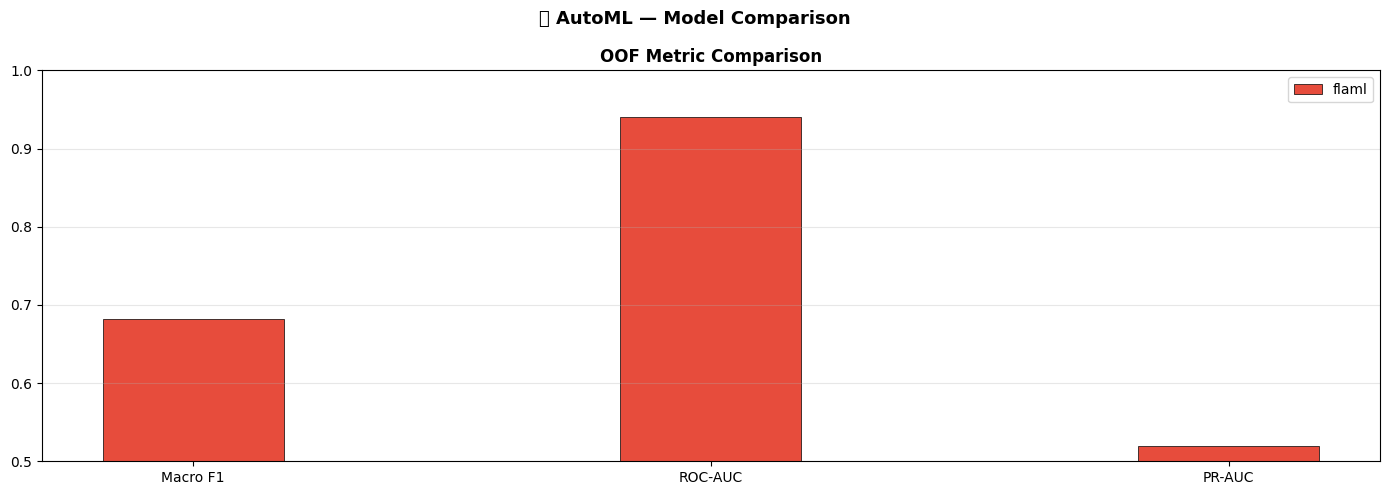

In [9]:
# ==============================================================================
# CELL 8: HEAD-TO-HEAD COMPARISON
# ==============================================================================
set_seed()

avail = {n: p for n, p in OOF.items()}
print(f"  {'Model':<16} {'Macro F1':>9} {'F1-C1':>7} "
      f"{'ROC-AUC':>9} {'PR-AUC':>8} {'Thresh':>7} {'Pred-1s':>8}")
print("  " + "─" * 60)

rows = []
for name, oof_p in avail.items():
    opt_t, opt_f1 = find_best_threshold(y, oof_p)
    pred = (oof_p >= opt_t).astype(int)
    rows.append({
        'name'    : name,
        'macro_f1': opt_f1,
        'f1_c1'   : f1_score(y, pred, pos_label=1, average='binary'),
        'roc_auc' : roc_auc_score(y, oof_p),
        'pr_auc'  : average_precision_score(y, oof_p),
        'thresh'  : opt_t,
        'pred_1s' : int(pred.sum()),
    })
    print(f"  {name:<16} {opt_f1:>9.4f} "
          f"{rows[-1]['f1_c1']:>7.4f} {rows[-1]['roc_auc']:>9.4f} "
          f"{rows[-1]['pr_auc']:>8.4f} {opt_t:>7.3f} {rows[-1]['pred_1s']:>8,}")

best_row   = max(rows, key=lambda r: r['macro_f1'])
FINAL_OOF  = OOF[best_row['name']]
FINAL_TEST = TEST[best_row['name']]
FINAL_T    = best_row['thresh']
FINAL_NAME = best_row['name']
print(f"\n✅ Best: {FINAL_NAME}  (OOF Macro F1 = {best_row['macro_f1']:.4f})")

# ── Visual comparison ─────────────────────────────────────────────────────────
n_models = len(avail)
fig = plt.figure(figsize=(14, 5 if n_models == 1 else 9))
col_map = {'flaml':'#E74C3C','autogluon':'#2ECC71'}

if n_models == 1:
    axes_flat = [plt.gca()]
else:
    gs = gridspec.GridSpec(1, 2, figure=fig, wspace=0.3)
    axes_flat = [fig.add_subplot(gs[0, i]) for i in range(2)]

# Bar chart of metrics
ax = axes_flat[0]
metrics   = ['macro_f1','roc_auc','pr_auc']
x         = np.arange(len(metrics))
bar_w     = 0.35 / max(len(rows), 1)
for i, r in enumerate(rows):
    vals = [r['macro_f1'], r['roc_auc'], r['pr_auc']]
    ax.bar(x + i*bar_w, vals, bar_w,
           color=col_map.get(r['name'],'#9B59B6'),
           label=r['name'], edgecolor='k', lw=0.5)
ax.set_xticks(x + bar_w*(len(rows)-1)/2)
ax.set_xticklabels(['Macro F1','ROC-AUC','PR-AUC'])
ax.set_ylim(0.5, 1.0); ax.legend()
ax.set_title('OOF Metric Comparison', fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

if n_models > 1:
    # Score distributions
    ax2 = axes_flat[1]
    for name, oof_p in avail.items():
        ax2.hist(oof_p[y==1], bins=50, alpha=0.5, density=True,
                 color=col_map.get(name,'gray'), label=f'{name} (class-1)')
    ax2.set_title('OOF Score Distribution — Class-1', fontweight='bold')
    ax2.set_xlabel('Predicted Probability')
    ax2.legend(); ax2.grid(True, alpha=0.3)

plt.suptitle('🤖 AutoML — Model Comparison', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig(BASE_DIR / 'automl_comparison.png', bbox_inches='tight')
plt.show()


---
## Cell 9 — 🎯 Threshold Optimisation & Submission

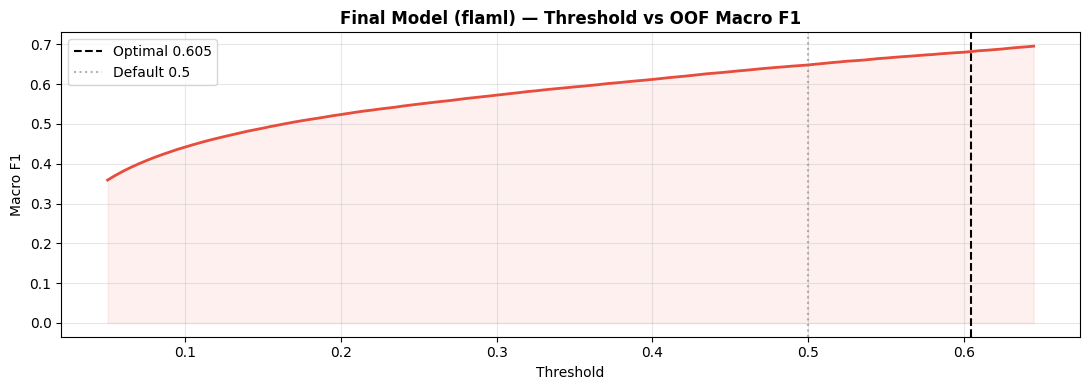

🎯 Final model   : flaml
   Threshold     : 0.605  (F1-optimal)
   Class 0       : 54,746 (90.26%)
   Class 1       : 5,908 (9.74%)

✅ All checks passed.
💾 Saved: submissions\submission_automl_20260812_091518.csv


In [10]:
# ==============================================================================
# CELL 9: SUBMISSION
# ==============================================================================
set_seed()

# Show full threshold analysis for the winning model
thresholds = np.arange(0.05, 0.65, 0.005)
f1_curve   = [f1_score(y, (FINAL_OOF>=t).astype(int), average='macro')
              for t in thresholds]

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(thresholds, f1_curve, color='#E74C3C', lw=2)
ax.fill_between(thresholds, f1_curve, alpha=0.08, color='#E74C3C')
ax.axvline(FINAL_T, color='black', ls='--', lw=1.5, label=f'Optimal {FINAL_T}')
ax.axvline(0.5, color='gray', ls=':', alpha=0.6, label='Default 0.5')
ax.set_title(f'Final Model ({FINAL_NAME}) — Threshold vs OOF Macro F1',
             fontweight='bold')
ax.set_xlabel('Threshold'); ax.set_ylabel('Macro F1')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(BASE_DIR / 'automl_final_threshold.png', bbox_inches='tight')
plt.show()

# ── Build submission ──────────────────────────────────────────────────────────
final_binary = (FINAL_TEST >= FINAL_T).astype(int)
pred_counts  = np.bincount(final_binary)

sub_df = pd.DataFrame({'id': test_ids, 'TARGET': final_binary})
sub_df = df_sub[['id']].merge(sub_df, on='id', how='left')
sub_df['TARGET'] = sub_df['TARGET'].fillna(0).astype(int)

# Integrity checks
assert list(sub_df.columns) == ['id', 'TARGET'], "Column mismatch!"
assert len(sub_df) == len(df_sub),               "Row count mismatch!"
assert sub_df['TARGET'].isin([0, 1]).all(),       "Non-binary TARGET!"

TIMESTAMP = datetime.now().strftime('%Y%m%d_%H%M%S')
sub_path  = SUBMISSIONS_DIR / f'submission_automl_{TIMESTAMP}.csv'
sub_df.to_csv(sub_path, index=False)

print(f"🎯 Final model   : {FINAL_NAME}")
print(f"   Threshold     : {FINAL_T:.3f}  (F1-optimal)")
print(f"   Class 0       : {pred_counts[0]:,} ({pred_counts[0]/len(final_binary)*100:.2f}%)")
print(f"   Class 1       : {pred_counts[1]:,} ({pred_counts[1]/len(final_binary)*100:.2f}%)")
print(f"\n✅ All checks passed.")
print(f"💾 Saved: {sub_path}")

SUBMISSION_META = {
    'timestamp'  : TIMESTAMP,
    'filename'   : str(sub_path),
    'final_model': FINAL_NAME,
    'threshold'  : float(FINAL_T),
    'pred_class_0': int(pred_counts[0]),
    'pred_class_1': int(pred_counts[1]),
    'models_run' : list(OOF.keys()),
    'flaml_version': flaml.__version__,
}


---
## Cell 10 — 📄 Report Generation
> **⚠️ STANDALONE — run after Cell 9. Safe to delete.**

In [11]:
# ==============================================================================
# CELL 10: REPORT GENERATION  [STANDALONE — DELETABLE]
# ==============================================================================
report_ts   = datetime.now().strftime('%Y%m%d_%H%M%S')
report_path = REPORTS_DIR / f'report_automl_{report_ts}.txt'

fp  = (FINAL_OOF >= FINAL_T).astype(int)
cm  = confusion_matrix(y, fp)
cr  = classification_report(y, fp, target_names=['Stable','At-Risk'])
macro_f1  = f1_score(y, fp, average='macro')
roc_auc   = roc_auc_score(y, FINAL_OOF)
pr_auc    = average_precision_score(y, FINAL_OOF)
SEP, THIN = '='*70, '-'*70

lines = [
    SEP,
    '  CARNIVAL — AutoML Report (notebook-automl.ipynb)',
    SEP,
    f'  Generated  : {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}',
    f'  Submission : {SUBMISSION_META["filename"]}',
    '',
    THIN, '  AUTOML CONFIGURATION', THIN,
    f'  FLAML version : {SUBMISSION_META["flaml_version"]}',
    f'  FLAML budget  : {FLAML_BUDGET//60} min',
    f'  AutoGluon     : {"ran" if AUTOGLUON_AVAILABLE else "not installed"}',
    f'  AG budget     : {AG_BUDGET//60} min  (if ran)',
    f'  CV folds      : {N_FOLDS}',
    '',
    THIN, '  FEATURE ENGINEERING', THIN,
    f'  Smoothed target encoding for {len(ACTIVE_CAT)} categorical features',
    f'  13 row-level statistical features added',
    f'  Zero-variance features dropped',
    f'  Final feature count: {df_train_fe.shape[1]-1}',
    '',
    THIN, '  MODEL COMPARISON', THIN,
    f'  {"Model":<16} {"Macro F1":>9} {"Threshold":>10}',
    '  ' + '-'*40,
] + [f'  {r["name"]:<16} {r["macro_f1"]:>9.4f} {r["thresh"]:>10.3f}'
     for r in rows] + [
    '',
    THIN, '  FINAL MODEL', THIN,
    f'  Selected  : {SUBMISSION_META["final_model"]}',
    f'  Threshold : {SUBMISSION_META["threshold"]:.3f}  (F1-optimal)',
    f'  Macro F1  : {macro_f1:.4f}',
    f'  ROC-AUC   : {roc_auc:.4f}',
    f'  PR-AUC    : {pr_auc:.4f}',
    '',
    '  Confusion Matrix (OOF):',
    f'    True\\Pred  |  Stable   | At-Risk',
    f'    Stable     | {cm[0,0]:9,} | {cm[0,1]:7,}',
    f'    At-Risk    | {cm[1,0]:9,} | {cm[1,1]:7,}',
    '',
    '  Classification Report:',
] + [f'  {l}' for l in cr.split('\n')] + [
    '',
    THIN, '  SUBMISSION', THIN,
    f'  Class 0  : {SUBMISSION_META["pred_class_0"]:,}',
    f'  Class 1  : {SUBMISSION_META["pred_class_1"]:,}',
    '',
    THIN, '  FUTURE IMPROVEMENTS', THIN,
    '  • Increase FLAML time_budget to 2–4 hours for deeper search',
    '  • Install AutoGluon for full 2-level stacking ensemble',
    '  • Combine AutoML OOF probs with custom notebook-stack.ipynb probs',
    '  • Use AutoGluon feature importance to prune weak features',
    '  • Try AutoGluon "high_quality" preset for faster iteration',
    '',
    SEP, '  END OF REPORT', SEP,
]
text = '\n'.join(lines)
with open(report_path, 'w') as f:
    f.write(text)
print(text)
print(f"\n💾 Report: {report_path}")


  CARNIVAL — AutoML Report (notebook-automl.ipynb)
  Generated  : 2026-08-12 09:15:18
  Submission : submissions\submission_automl_20260812_091518.csv

----------------------------------------------------------------------
  AUTOML CONFIGURATION
----------------------------------------------------------------------
  FLAML version : 2.6.0
  FLAML budget  : 45 min
  AutoGluon     : not installed
  AG budget     : 60 min  (if ran)
  CV folds      : 5

----------------------------------------------------------------------
  FEATURE ENGINEERING
----------------------------------------------------------------------
  Smoothed target encoding for 6 categorical features
  13 row-level statistical features added
  Zero-variance features dropped
  Final feature count: 341

----------------------------------------------------------------------
  MODEL COMPARISON
----------------------------------------------------------------------
  Model             Macro F1  Threshold
  ----------------------